<a href="https://colab.research.google.com/github/SravaniLadi/Predictive-Modelling-of-Parkinson-s-Disease-Using-Speech-Biomarkers-and-Tremor-Based-Features/blob/main/PD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

# ── 1. Load raw datasets ──────────────────────────────────────────────────────
df_meander = pd.read_csv("/content/Meander_HandPD.csv")
df_parkinson = pd.read_csv("/content/Parkinsson disease.csv")

print("=" * 60)
print("DATASET OVERVIEW (Before Merge)")
print("=" * 60)
overview_before = pd.DataFrame({
    "Dataset Name":   ["Meander_HandPD", "Parkinsson_disease"],
    "Rows":           [len(df_meander), len(df_parkinson)],
    "Columns":        [len(df_meander.columns), len(df_parkinson.columns)],
})
print(overview_before.to_string(index=False))
print()

# ── 2. Add source-tracking column ────────────────────────────────────────────
df_meander   = df_meander.copy()
df_parkinson = df_parkinson.copy()

df_meander["source_dataset"]   = "Meander_HandPD"
df_parkinson["source_dataset"] = "Parkinsson_disease"

# ── 3. Vertical concatenation (union) ────────────────────────────────────────
#   axis=0  → stack rows on top of each other
#   ignore_index=True → reset integer index in merged frame
#   Columns unique to one dataset become NaN in rows from the other.
merged_df = pd.concat([df_meander, df_parkinson], axis=0, ignore_index=True)

print(f"Shape after concat (before imputation): {merged_df.shape}")
print(f"Missing values after concat: {merged_df.isnull().sum().sum()}")
print()

# ── 4. Missing value imputation ───────────────────────────────────────────────
# Separate columns by dtype
numeric_cols     = merged_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = merged_df.select_dtypes(exclude=[np.number]).columns.tolist()
# Remove source_dataset from categorical imputation (already fully filled)
categorical_cols = [c for c in categorical_cols if c != "source_dataset"]

# 4a. Numeric → median imputation
for col in numeric_cols:
    median_val = merged_df[col].median()
    merged_df[col] = merged_df[col].fillna(median_val)

# 4b. Categorical/text → fill with "N/A"
for col in categorical_cols:
    merged_df[col] = merged_df[col].fillna("N/A")

# ── 5. Validation ─────────────────────────────────────────────────────────────
final_rows    = len(merged_df)
final_cols    = len(merged_df.columns)
missing_cells = merged_df.isnull().sum().sum()

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)
print(f"  Total rows      : {final_rows}   (expected: 563)")
print(f"  Total columns   : {final_cols}   (expected: 41)")
print(f"  Empty cells     : {missing_cells}   (expected: 0)")
print()

assert final_rows == 563,    f"Row count mismatch: got {final_rows}"
assert final_cols == 41,     f"Column count mismatch: got {final_cols}"
assert missing_cells == 0,   f"Still has missing values: {missing_cells}"
print("  ✅ All assertions passed.")
print()

# ── 6. Dataset overview table ────────────────────────────────────────────────
overview_after = pd.DataFrame({
    "Dataset Name":   ["Meander_HandPD", "Parkinsson_disease", "Merged_PD_Dataset"],
    "Rows":           [len(df_meander), len(df_parkinson), final_rows],
    "Columns":        [
        len(df_meander.columns),
        len(df_parkinson.columns),
        final_cols,
    ],
})
print("=" * 60)
print("DATASET OVERVIEW TABLE")
print("=" * 60)
print(overview_after.to_string(index=False))
print()

# ── 7. Preprocessing techniques summary ──────────────────────────────────────
print("=" * 60)
print("PREPROCESSING TECHNIQUES APPLIED")
print("=" * 60)
print("  1. Vertical Concatenation   — pd.concat(axis=0) stacks rows from")
print("                                both datasets, creating NaN where")
print("                                a column doesn't exist in one source.")
print()
print("  2. Source Tracking Column   — 'source_dataset' column identifies")
print("                                the origin of every row.")
print()
print("  3. Missing Value Imputation — Numeric columns filled with column")
print("                                median; text/categorical columns")
print("                                filled with the string \"N/A\".")
print()

# ── 8. Why vertical, not horizontal? ─────────────────────────────────────────
print("=" * 60)
print("WHY VERTICAL CONCATENATION?")
print("=" * 60)
print("""
  Vertical concatenation (axis=0) is appropriate here because the two
  datasets share ZERO common columns — Meander_HandPD captures spiral-
  drawing hand-motion features (image metrics, stroke heights, etc.)
  while Parkinsson_disease captures vocal biomarkers (jitter, shimmer,
  RPDE, DFA, etc.).

  Horizontal merging (pd.merge or pd.concat axis=1) would require a
  common key (e.g., patient ID) so that each row in one dataset pairs
  meaningfully with a row in the other. No such key exists here, and
  the patient populations are different, so a horizontal join would
  either:
    • Produce a Cartesian product (meaningless 71,760-row table), or
    • Discard nearly all rows on an inner join, losing data.

  Vertical union preserves every observation from both studies, lets
  each feature set remain sparse but interpretable, and is the standard
  approach when combining heterogeneous clinical sub-studies under one
  umbrella dataset.
""")

# ── 9. Save output ────────────────────────────────────────────────────────────
out_path = "/mnt/user-data/outputs/Merged_PD_Dataset.csv"
os.makedirs("/mnt/user-data/outputs/", exist_ok=True)
merged_df.to_csv(out_path, index=False)
print(f"  ✅ Merged dataset saved to: {out_path}")
print(f"     ({final_rows} rows × {final_cols} columns, 0 empty cells)")

# ── 10. Download merged dataset automatically ────────────────────────────────
from google.colab import files

files.download(out_path)

DATASET OVERVIEW (Before Merge)
      Dataset Name  Rows  Columns
    Meander_HandPD   368       16
Parkinsson_disease   195       24

Shape after concat (before imputation): (563, 41)
Missing values after concat: 11952

FINAL DATASET VALIDATION
  Total rows      : 563   (expected: 563)
  Total columns   : 41   (expected: 41)
  Empty cells     : 0   (expected: 0)

  ✅ All assertions passed.

DATASET OVERVIEW TABLE
      Dataset Name  Rows  Columns
    Meander_HandPD   368       17
Parkinsson_disease   195       25
 Merged_PD_Dataset   563       41

PREPROCESSING TECHNIQUES APPLIED
  1. Vertical Concatenation   — pd.concat(axis=0) stacks rows from
                                both datasets, creating NaN where
                                a column doesn't exist in one source.

  2. Source Tracking Column   — 'source_dataset' column identifies
                                the origin of every row.

  3. Missing Value Imputation — Numeric columns filled with column
                

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


Dataset Shape: (563, 41)
   _ID_EXAM  IMAGE_NAME  ID_PATIENT  CLASS_TYPE GENDER RIGH/LEFT-HANDED   AGE  \
0      68.0  0068-1.jpg         1.0         1.0      F                L  28.0   
1      68.0  0068-2.jpg         1.0         1.0      F                L  28.0   
2      68.0  0068-3.jpg         1.0         1.0      F                L  28.0   
3      68.0  0068-4.jpg         1.0         1.0      F                L  28.0   
4      92.0  0092-1.jpg         2.0         1.0      M                R  37.0   

           RMS  MAX_BETWEEN_ST_HT  MIN_BETWEEN_ST_HT  ...  Shimmer:DDA  \
0  3176.216064        7098.378906        46569.03516  ...      0.03836   
1  2751.015869        6263.803711        44059.59766  ...      0.03836   
2  3050.623779        6548.623047        40298.10938  ...      0.03836   
3  2594.598877        6989.159180        54217.63281  ...      0.03836   
4  3310.786865        6060.232422        35212.75781  ...      0.03836   

       NHR     HNR  status      RPDE       

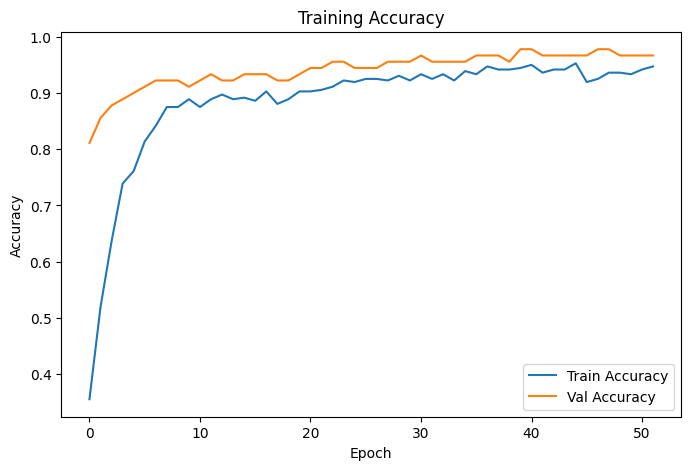

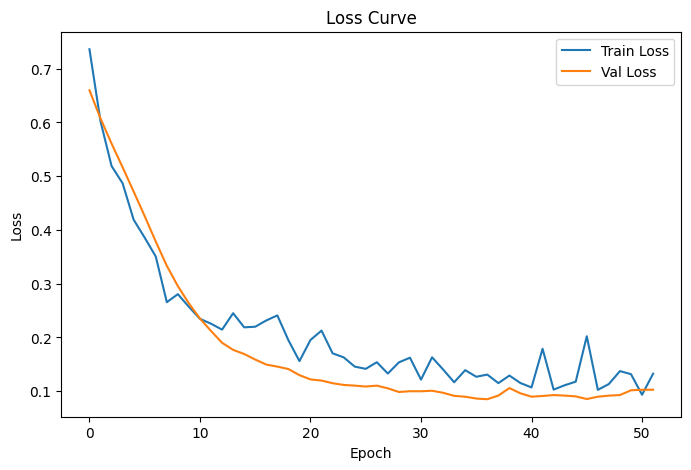

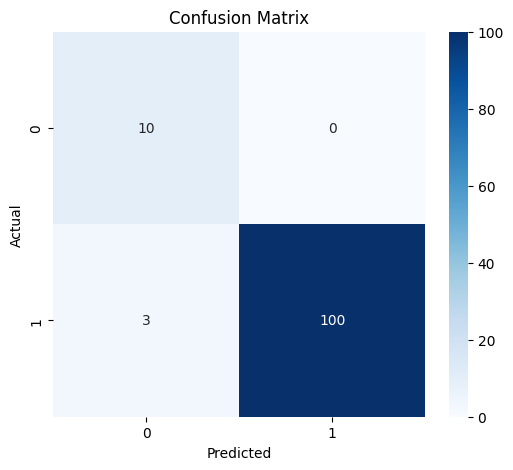

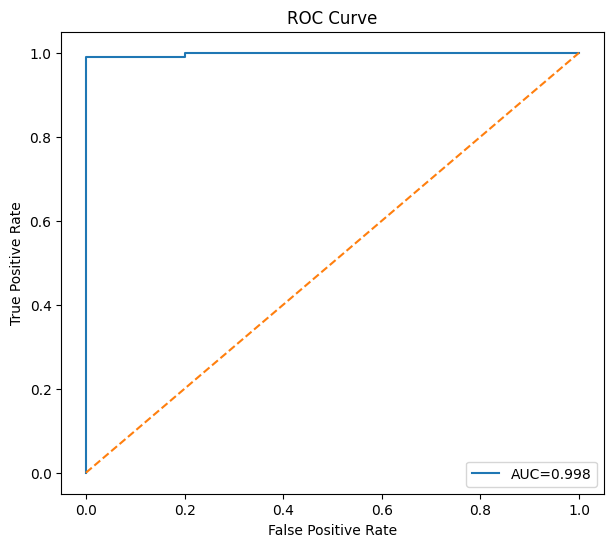

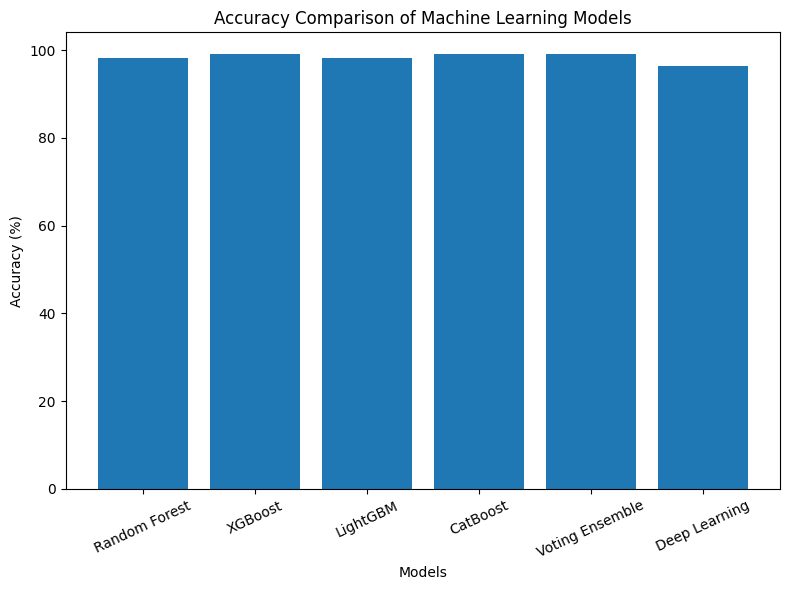

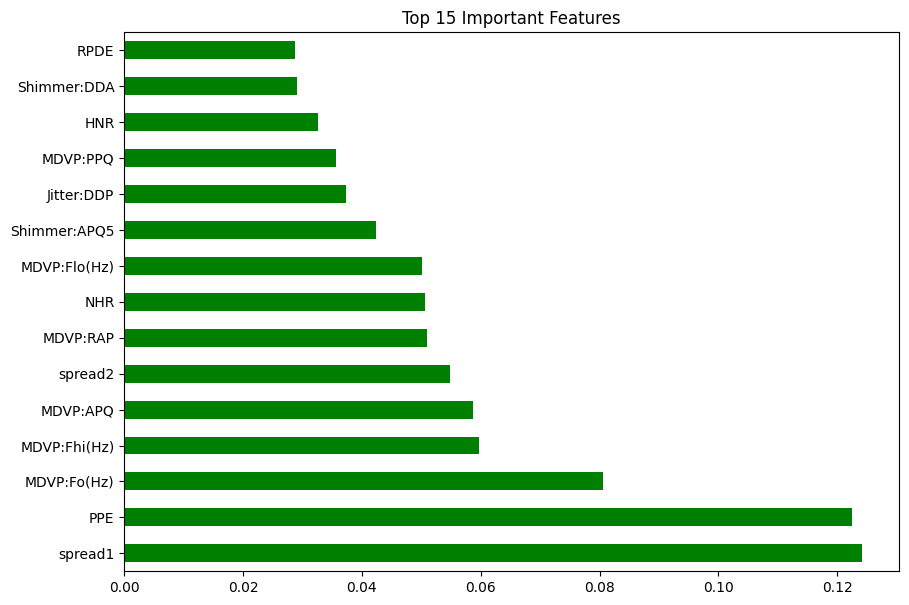


Model saved successfully!


In [ ]:
# ==========================================
# Parkinson Disease Prediction Project
# Voice Biomarkers + Hand Tremor
# Advanced Models + Deep Learning + Visualization
# ==========================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    BatchNormalization, Concatenate
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv("/content/Merged_PD_Dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ==========================================
# Drop unwanted columns
# ==========================================
drop_cols = [
    "_ID_EXAM",
    "IMAGE_NAME",
    "ID_PATIENT",
    "name",
    "source_dataset"
]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)


# ==========================================
# Target
# ==========================================
target = "status"

y = df[target]
X = df.drop(target, axis=1)


# ==========================================
# Encode categorical columns
# ==========================================
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


# ==========================================
# Missing values
# ==========================================
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


# ==========================================
# Separate Voice and Tremor Features
# ==========================================
voice_keywords = [
    'MDVP', 'Jitter', 'Shimmer',
    'NHR', 'HNR', 'RPDE',
    'DFA', 'spread', 'PPE',
    'Fo', 'Fhi', 'Flo'
]

tremor_keywords = [
    'RMS', 'MRT', 'MAX_HT',
    'MIN_HT', 'STD_HT',
    'FREQ', 'AMPLITUDE',
    'TREMOR'
]

voice_features = [
    col for col in X.columns
    if any(k.lower() in col.lower() for k in voice_keywords)
]

tremor_features = [
    col for col in X.columns
    if any(k.lower() in col.lower() for k in tremor_keywords)
]

print("Voice:", voice_features)
print("Tremor:", tremor_features)

X_voice = X[voice_features]
X_tremor = X[tremor_features]


# ==========================================
# Split
# ==========================================
Xv_train, Xv_test, Xt_train, Xt_test, y_train, y_test = train_test_split(
    X_voice,
    X_tremor,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# Scaling
# ==========================================
scaler_voice = StandardScaler()
scaler_tremor = StandardScaler()

Xv_train = scaler_voice.fit_transform(Xv_train)
Xv_test = scaler_voice.transform(Xv_test)

Xt_train = scaler_tremor.fit_transform(Xt_train)
Xt_test = scaler_tremor.transform(Xt_test)


# Combined features for ML models
X_train_combined = np.concatenate([Xv_train, Xt_train], axis=1)
X_test_combined = np.concatenate([Xv_test, Xt_test], axis=1)


# ==========================================
# Class Weights
# ==========================================
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))


# ==========================================
# Advanced ML Models
# ==========================================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss'
)

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    verbose=-1,
    verbosity=-1,
    force_col_wise=True
)

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    verbose=0
)

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('cat', cat)
    ],
    voting='soft'
)

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat,
    "Voting Ensemble": ensemble
}


print("\n===== ML MODEL RESULTS =====")

for name, model in models.items():
    model.fit(X_train_combined, y_train)

    preds = model.predict(X_test_combined)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_combined)[:, 1]
        auc = roc_auc_score(y_test, probs)
    else:
        auc = 0

    acc = accuracy_score(y_test, preds)

    print(f"{name}")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print("-" * 40)


# ==========================================
# Deep Learning Model
# ==========================================
voice_input = Input(shape=(Xv_train.shape[1],))

x1 = Dense(128, activation='relu')(voice_input)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)

x1 = Dense(64, activation='relu')(x1)
x1 = Dropout(0.3)(x1)


tremor_input = Input(shape=(Xt_train.shape[1],))

x2 = Dense(128, activation='relu')(tremor_input)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)

x2 = Dense(64, activation='relu')(x2)
x2 = Dropout(0.3)(x2)


combined = Concatenate()([x1, x2])

z = Dense(64, activation='relu')(combined)
z = BatchNormalization()(z)
z = Dropout(0.4)(z)

z = Dense(32, activation='relu')(z)
output = Dense(1, activation='sigmoid')(z)

dl_model = Model(
    inputs=[voice_input, tremor_input],
    outputs=output
)

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    )
]


history = dl_model.fit(
    [Xv_train, Xt_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


# ==========================================
# Evaluate Deep Learning
# ==========================================
loss, acc, auc = dl_model.evaluate(
    [Xv_test, Xt_test],
    y_test,
    verbose=0
)

print("\nDeep Learning Accuracy:", acc)
print("Deep Learning AUC:", auc)


y_prob = dl_model.predict([Xv_test, Xt_test], verbose=0)
y_pred = (y_prob > 0.5).astype(int)


print(classification_report(y_test, y_pred))


# ==========================================
# Visualization 1: Training History
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


# ==========================================
# Visualization 2: Loss Curve
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# ==========================================
# Visualization 3: Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==========================================
# Visualization 4: ROC Curve
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


models = ["Random Forest", "XGBoost", "LightGBM", "CatBoost", "Voting Ensemble", "Deep Learning"]
accuracy = [98.23, 99.11, 98.23, 99.11, 99.11, 96.46]

plt.figure(figsize=(8,6))
plt.bar(models, accuracy)
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# ==========================================
# Feature Importance (Random Forest)
# ==========================================
rf.fit(X_train_combined, y_train)

importances = rf.feature_importances_

feature_names = voice_features + tremor_features

feat_imp = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='green')
plt.title("Top 15 Important Features")
plt.show()


# ==========================================
# Save model
# ==========================================
dl_model.save("pd_multimodal_model.h5")

print("\nModel saved successfully!")